In [84]:
# ----------------------------
# 1) Setup
# ----------------------------
from dotenv import load_dotenv

load_dotenv()
import uuid
from typing import List, Annotated, TypedDict
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import SystemMessage, BaseMessage
from langgraph.graph.message import add_messages  # optimised reducer for message state
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

import os

In [85]:
os.environ["LANGCHAIN_PROJECT"] = "chatbot_with_long_and_short_mem"


In [86]:
# ----------------------------
# 2) Long-term memory store (semantic index over embeddings)
# ----------------------------
embedding_model = OpenAIEmbeddings(model='text-embedding-3-small')
store = InMemoryStore(index={'embed': embedding_model, 'dims': 1536})

In [87]:
# ----------------------------
# 3) Graph state
# ----------------------------
class chatstate(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [88]:
# ----------------------------
# 4) Structured-output schemas for the memory extractor
# ----------------------------
class MemoryItem(BaseModel):
    text: Annotated[str, Field(description="Atomic user memory")]
    is_new: Annotated[bool, Field(description="True if new, false if duplicate")]

class MemoryDecision(BaseModel):
    should_write: bool
    memories: Annotated[List[MemoryItem], Field(default_factory=list)]

In [89]:
# ----------------------------
# 5) LLMs
# ----------------------------
extractor_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(MemoryDecision)
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [90]:
# ----------------------------
# 6) Prompt templates
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant. Use the known details about the user below to \
personalize your replies. Don't mention that you're using stored memories.

Known details about the user:
{user_details_content}
"""

In [91]:
MEMORY_PROMPT_TEMPLATE = """You maintain long-term memory about the user for a conversational assistant.

Existing known details about the user:
{user_details_content}

Read the user's latest message and decide whether it contains new, durable facts worth remembering \
(e.g. name, role, preferences, goals). Only extract atomic facts that are not already present above. \
If nothing new and memorable is present, set should_write to False and return no memories.
"""

In [92]:
# ----------------------------
# 7) Nodes
# ----------------------------
def remember_node(state: chatstate, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    # existing memory
    items = store.search(namespace)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = extractor_llm.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT_TEMPLATE.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {}

In [93]:
def chat_node(state: chatstate, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    items = store.search(namespace, query=state["messages"][-1].content, limit=3)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

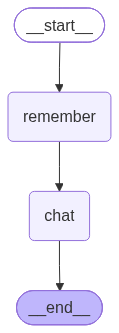

In [94]:
# ----------------------------
# 8) Graph
# ----------------------------
builder = StateGraph(chatstate)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [95]:
# ----------------------------
# 9) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [96]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Amitoj Singh Chawla"}]}, config)
result['messages'][-1].content

"Hi Amitoj! It's nice to meet you. How can I assist you today?"

In [97]:
result = graph.invoke({"messages": [{"role": "user", "content": "I am a beginner AI Engineer "}]}, config)
result['messages'][-1].content

"That's great, Amitoj! As a beginner AI Engineer, there are so many exciting concepts and technologies to explore. What specific areas of AI are you most interested in learning about, or are there any projects you're currently working on?"

In [99]:
result = graph.invoke({"messages": [{"role": "user", "content": "how are you "}]}, config)
result['messages'][-1].content

"I'm doing well, thank you! How about you, Amitoj? How's your journey into AI engineering going?"

In [101]:
result = graph.invoke({"messages": [{"role": "user", "content": "i like chocolate cake"}]}, config)
result['messages'][-1].content

"That's great to hear, Amitoj! Chocolate cake is such a classic favorite. Do you have a favorite recipe or place where you like to get it?"

In [102]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Amitoj Singh Chawla
Amitoj Singh Chawla is a beginner AI Engineer.
Amitoj Singh Chawla likes chocolate cake.
